In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_absolute_percentage_error

sns.set(style="whitegrid")

In [ ]:
def load_and_prep(file_path, month_name):
    df = pd.read_csv(file_path)
    df['Month'] = month_name
    return df

jan_data = load_and_prep('inv_jan01.csv', 'January')
feb_data = load_and_prep('inv_feb01.csv', 'February')
mar_actual = load_and_prep('inv_mar01.csv', 'March')

history = pd.concat([jan_data, feb_data])
print(f"History data loaded. Total entries: {len(history)}")

History data loaded. Total entries: 300


In [ ]:
predictions = []
medicines = history['Item_ID'].unique()

for med in medicines:
    med_series = history[history['Item_ID'] == med]['Current_Stock'].values

    model = SimpleExpSmoothing(med_series).fit(smoothing_level=0.5, optimized=False)
    forecast = model.forecast(1)[0]

    predictions.append({'Medicine_ID': med, 'Predicted_Stock': round(forecast, 2)})

df_pred = pd.DataFrame(predictions)
print("Forecast for March completed.")

Forecast for March completed.


In [ ]:

if 'Medicine_ID' in df_pred.columns:
    df_pred.rename(columns={'Medicine_ID': 'Item_ID'}, inplace=True)

comparison = pd.merge(df_pred, mar_actual[['Item_ID', 'Current_Stock']], on='Item_ID')
comparison.rename(columns={'Current_Stock': 'Actual_Stock'}, inplace=True)

valid_comparison = comparison[comparison['Actual_Stock'] > 0].copy()

if not valid_comparison.empty:
    mape = mean_absolute_percentage_error(valid_comparison['Actual_Stock'], valid_comparison['Predicted_Stock'])
    accuracy = max(0, (1 - mape) * 100)
else:
    mape = None
    accuracy = 0
    print("Warning: Actual_Stock contains only zeros. Cannot calculate MAPE.")

print(f"--- Model Results ---")
print(comparison.head())
print(f"\nFinal Prediction Accuracy: {accuracy:.2f}%")

--- Model Results ---
  Item_ID  Predicted_Stock  Actual_Stock
0  RX-001            505.0           504
1  RX-002            345.0           345
2  RX-003            990.0          1020
3  RX-004            205.0           205
4  RX-005           1525.0          1520

Final Prediction Accuracy: 99.04%


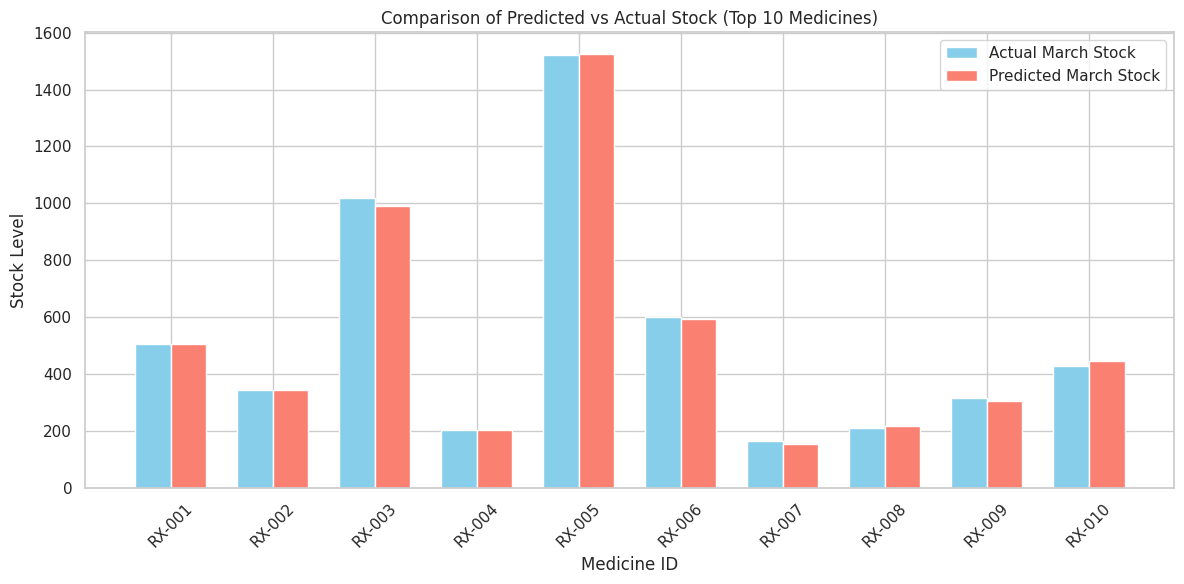

In [ ]:
plt.figure(figsize=(12, 6))

top_10 = comparison.head(10)
x = np.arange(len(top_10))
width = 0.35

plt.bar(x - width/2, top_10['Actual_Stock'], width, label='Actual March Stock', color='skyblue')
plt.bar(x + width/2, top_10['Predicted_Stock'], width, label='Predicted March Stock', color='salmon')

plt.xlabel('Medicine ID')
plt.ylabel('Stock Level')
plt.title('Comparison of Predicted vs Actual Stock (Top 10 Medicines)')
plt.xticks(x, top_10['Item_ID'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()